# CISM Tutorial 02: FANMOD+, Initialization, And Stringency Selection

This notebook starts from the output of tutorial 01.

By the end of this notebook you should have:

- a validated prepared dataset folder
- a loaded `CISM` object
- a `TissueStateDiscriminativeMotifs` object
- a discriminative-motifs-versus-stringency plot
- an AUC-based choice of stringency parameters
- a serialized artifact you can load in later analysis notebooks

## What This Notebook Covers

This notebook performs the transition from prepared graph txt files to an analysis-ready CISM state.

It will:

1. reuse the `network_dataset_root_path` and `dataset_folder` from tutorial 01
2. resolve the FANMOD+ binary already bundled in this repository
3. create tutorial-local `fanmod_output` and `fanmod_cache` folders
4. initialize `CISM`
5. load the prepared dataset
6. construct a discriminator
7. inspect discriminative motifs versus stringency
8. choose a stringency parameter using Random Forest ROC AUC
9. save a reusable pickle artifact for downstream notebooks

## Notes About FANMOD+ Binaries

This tutorial uses the FANMOD+ binaries already stored under `cism/FANMOD_binaries/`.

For tutorial purposes this is simpler and safer than moving them now, because the notebook can stay fully self-contained and directly point `CISM` to the repo-bundled executable.

In [1]:
from pathlib import Path
import pickle
import platform

import pandas as pd

from cism import (
    CISM,
    DiscriminativeFeatureKey,
    HardDiscriminativeFC,
    TissueStateDiscriminativeMotifs,
    validate_network_dataset_directory,
)


In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "tutorials" else Path.cwd().resolve()
TUTORIALS_DIR = PROJECT_ROOT / "tutorials"
TUTORIAL_RUNTIME_DIR = TUTORIALS_DIR / "runtime"
FANMOD_OUTPUT_ROOT = TUTORIAL_RUNTIME_DIR / "fanmod_output"
FANMOD_CACHE_ROOT = TUTORIAL_RUNTIME_DIR / "fanmod_cache"
SERIALIZED_ROOT = TUTORIAL_RUNTIME_DIR / "serialized"

FANMOD_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
FANMOD_CACHE_ROOT.mkdir(parents=True, exist_ok=True)
SERIALIZED_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Tutorial runtime directory: {TUTORIAL_RUNTIME_DIR}")
print(f"fanmod_output_root_path: {FANMOD_OUTPUT_ROOT}")
print(f"fanmod_cache_root_path: {FANMOD_CACHE_ROOT}")
print(f"serialized artifact directory: {SERIALIZED_ROOT}")


Project root: /home/omriavit/CISM/CISM_paper_revision
Tutorial runtime directory: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime
fanmod_output_root_path: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/fanmod_output
fanmod_cache_root_path: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/fanmod_cache
serialized artifact directory: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/serialized


## Paste The Handoff Values From Tutorial 01

At the end of tutorial 01, the notebook printed these exact values:

- `network_dataset_root_path`
- `dataset_folder`

Use them directly here.

In [3]:
# Replace these with the values printed at the end of tutorial 01.
network_dataset_root_path = str(PROJECT_ROOT / "pet_data")
dataset_folder = "TNBC"  # Change this to the name of your dataset folder if it's different.

dataset_dir = Path(network_dataset_root_path) / dataset_folder
print(f"network_dataset_root_path = {network_dataset_root_path}")
print(f"dataset_folder = {dataset_folder}")
print(f"dataset_dir = {dataset_dir}")


network_dataset_root_path = /home/omriavit/CISM/CISM_paper_revision/pet_data
dataset_folder = TNBC
dataset_dir = /home/omriavit/CISM/CISM_paper_revision/pet_data/TNBC


In [4]:
# Confirm that tutorial 01 produced a valid folder.
txt_files = validate_network_dataset_directory(dataset_dir, require_patient_class=True)
print(f"Validated {len(txt_files)} txt graph files in {dataset_dir}")


Validated 38 txt graph files in /home/omriavit/CISM/CISM_paper_revision/pet_data/TNBC


## Resolve The FANMOD+ Binary

The `CISM` object expects:

- `fanmod_path`: directory containing the binary
- `fanmod_exe`: the executable filename

In [5]:
fanmod_path = PROJECT_ROOT / "FANMOD_binaries"
if platform.system().lower().startswith("win"):
    fanmod_exe = "LocalFANMOD - Windows"
else:
    fanmod_exe = "LocalFANMOD"

fanmod_binary_path = fanmod_path / fanmod_exe
print(f"fanmod_path = {fanmod_path}")
print(f"fanmod_exe = {fanmod_exe}")
print(f"fanmod binary exists: {fanmod_binary_path.exists()}")
!chmod +x {fanmod_binary_path}  # Ensure the binary is executable.


fanmod_path = /home/omriavit/CISM/CISM_paper_revision/FANMOD_binaries
fanmod_exe = LocalFANMOD
fanmod binary exists: True


## Initialize `CISM`

This tutorial uses the requested defaults:

- `motif_size = 3`
- `iterations = 1000`

In [6]:
cism = CISM(
    fanmod_exe=fanmod_exe,
    fanmod_path=str(fanmod_path),
    network_dataset_root_path=network_dataset_root_path,
    fanmod_output_root_path=str(FANMOD_OUTPUT_ROOT),
    fanmod_cache_root_path=str(FANMOD_CACHE_ROOT),
    motif_size=3,
    iterations=1000,
)

cism


## Load The Prepared Dataset

Use the requested defaults when adding the dataset:

- `force_run_fanmod=False`
- `force_parse=False`
- `n_jobs=12`

In [7]:
# Replace dataset_type and dataset_name with the metadata you want in downstream analysis.
dataset_type = "Disease"
dataset_name = "TNBC"

# Set these True after changing graph preparation or cell-type mapping so stale FANMOD/cache
# artifacts cannot be reused. After one clean rebuild, you may switch them back to False.
force_run_fanmod = True
force_parse = True

cism.add_dataset(
    dataset_folder=dataset_folder,
    dataset_type=dataset_type,
    dataset_name=dataset_name,
    force_run_fanmod=force_run_fanmod,
    force_parse=force_parse,
    n_jobs=12,
    require_patient_class=True,
)


Running FANMOD:   0%|          | 0/38 [00:00<?, ?it/s]

/home/omriavit/CISM/CISM_paper_revision/FANMOD_binaries/LocalFANMOD -i /home/omriavit/CISM/CISM_paper_revision/pet_data/TNBC/Patient_10_FOV10.txt -o /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/fanmod_output/TNBC/3//10_10.csv -r 1000 -s 3 --colored_vertcies
/home/omriavit/CISM/CISM_paper_revision/FANMOD_binaries/LocalFANMOD -i /home/omriavit/CISM/CISM_paper_revision/pet_data/TNBC/Patient_12_FOV12.txt -o /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/fanmod_output/TNBC/3//12_12.csv -r 1000 -s 3 --colored_vertcies
/home/omriavit/CISM/CISM_paper_revision/FANMOD_binaries/LocalFANMOD -i /home/omriavit/CISM/CISM_paper_revision/pet_data/TNBC/Patient_11_FOV11.txt -o /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/fanmod_output/TNBC/3//11_11.csv -r 1000 -s 3 --colored_vertcies
/home/omriavit/CISM/CISM_paper_revision/FANMOD_binaries/LocalFANMOD -i /home/omriavit/CISM/CISM_paper_revision/pet_data/TNBC/Patient_14_FOV14.txt -o /home/omriavit/CISM/CISM_paper_revisio

Parsing FANMOD output:   0%|          | 0/38 [00:00<?, ?it/s]

parse csv: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/fanmod_output/TNBC/3/20_20.csv patient_num: 20, FOV: 20
parse csv: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/fanmod_output/TNBC/3/21_21.csv patient_num: 21, FOV: 21
parse csv: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/fanmod_output/TNBC/3/23_23.csv patient_num: 23, FOV: 23
parse csv: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/fanmod_output/TNBC/3/24_24.csv patient_num: 24, FOV: 24
parse csv: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/fanmod_output/TNBC/3/25_25.csv patient_num: 25, FOV: 25
parse csv: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/fanmod_output/TNBC/3/26_26.csv patient_num: 26, FOV: 26
parse csv: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/fanmod_output/TNBC/3/27_27.csv patient_num: 27, FOV: 27
parse csv: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/fanmod_output/TNBC/3/28_28.csv patient_num: 28, FOV: 28


In [8]:
motif_df = cism.motif_dataset()
print(f"Loaded motif rows: {0 if motif_df is None else len(motif_df)}")
display(motif_df.head() if motif_df is not None else None)


Loaded motif rows: 18817


,Patient,FOV,ID,Freq,Count,Mean_Freq,STD,z_score,p_value,motif,nunique_colors,Disease,Patient_uId
0,10,10,30006732,0.126950,6571,3.577100e-02,0.001409,64.733002,0.0,gASVMQEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,1,TNBC,TNBC10
1,10,10,17374476,0.055563,2876,2.259700e-02,0.001067,30.896000,0.0,gASVKgEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,1,TNBC,TNBC10
2,10,10,31317452,0.030158,1561,8.602500e-08,0.000001,27223.000000,0.0,gASVTwEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,1,TNBC,TNBC10
3,10,10,7722444,0.025521,1321,1.924400e-02,0.000713,8.807300,0.0,gASVMAEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,2,TNBC,TNBC10
4,10,10,7673100,0.019899,1030,1.423800e-02,0.000618,9.158700,0.0,gASVLAEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,2,TNBC,TNBC10


## Define The Analysis Metadata Needed For Discrimination

To analyze discriminative motifs, we need:

- a path to `patient_class.csv`
- a mapping from raw class values to readable labels
- a mapping from integer cell-type ids to cell-type names

Both mappings are dataset-specific, so replace the examples below with your real values.

In [9]:
# This TNBC dataset stores survival days, so we split patients into short- and long-term survival.
# You can change the cutoff for your own analysis question.
survival_rate_cutoff = 1000


def map_survival_rate_to_class(survival_rate: int):
    if survival_rate < survival_rate_cutoff:
        return "Short-term survival"
    return "Long-term survival"


labels = ["Short-term survival", "Long-term survival"]


In [10]:
tissue_state_csv_path = str(dataset_dir / "patient_class.csv")

# Use this mapping when patient_class.csv already contains readable categorical labels.
tissue_state_to_string = {
    "POSITIVE": "POSITIVE",
    "NEGATIVE": "NEGATIVE",
}

# Paste from tutorial 01 output. This is the graph color id -> cell-type name mapping.
common_cells_type = {
    0: "B cells",
    1: "CD3 T cells",
    2: "CD4 t cells",
    3: "CD8 T cells",
    4: "DC",
    5: "DC/Mono",
    6: "Endothelial",
    7: "Immune other",
    8: "Macrophages",
    9: "Mesenchyme",
    10: "Mono/Neu",
    11: "NK cells",
    12: "Neutrophils",
    13: "Tregs",
    14: "Tumor",
    15: "Unidentified",
}

patient_class_df = pd.read_csv(tissue_state_csv_path, index_col=0, names=["survival_days"])
motif_patient_uids = set(motif_df["Patient_uId"].astype(str).unique())
missing_tissue_state = sorted(motif_patient_uids - set(patient_class_df.index.astype(str)))

print(f"Patients with motif rows: {len(motif_patient_uids)}")
print(f"Patients with tissue-state labels: {len(patient_class_df)}")
print(f"Patients without tissue-state labels and excluded from discrimination: {missing_tissue_state}")
print(f"labels = {labels}")
print("common_cells_type =")
print(common_cells_type)


Patients with motif rows: 37
Patients with tissue-state labels: 37
Patients without tissue-state labels and excluded from discrimination: []
labels = ['Short-term survival', 'Long-term survival']
common_cells_type =
{0: 'B cells', 1: 'CD3 T cells', 2: 'CD4 t cells', 3: 'CD8 T cells', 4: 'DC', 5: 'DC/Mono', 6: 'Endothelial', 7: 'Immune other', 8: 'Macrophages', 9: 'Mesenchyme', 10: 'Mono/Neu', 11: 'NK cells', 12: 'Neutrophils', 13: 'Tregs', 14: 'Tumor', 15: 'Unidentified'}


In [11]:
discriminator = TissueStateDiscriminativeMotifs(
    cism=cism,
    tissue_state_csv_path=tissue_state_csv_path,
    tissue_state_to_string=None,  # Use tissue_state_to_string when labels are already categorical.
    common_cells_type=common_cells_type,
    tissue_state_func=map_survival_rate_to_class,
)

display(discriminator.get_patients_class(classes=None).groupby("patient_class").count())


,patient_class_id
patient_class,
Long-term survival,30
Short-term survival,7


## Plot Discriminative Motifs Per Stringency

This gives a first view of how many motifs remain as the discrimination stringency parameter increases.

Replace the colors if you prefer a different class palette.

/home/omriavit/.conda/envs/CISM/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


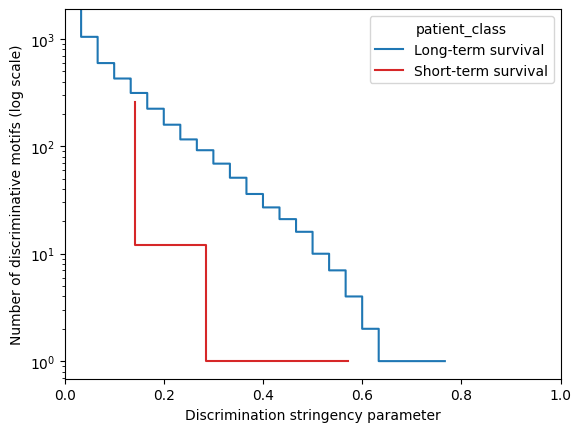

In [12]:
#warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

class_to_color = {
    labels[0]: "tab:red",
    labels[1]: "tab:blue",
}

discover_result = discriminator.discover(
    extract_by=DiscriminativeFeatureKey.STRUCTURE_AND_CELL_IDENTITIES,
    classes=labels,
)

discover_result.plot_number_of_motifs_versus_discrimination_stringency_parameter(
    class_to_color=class_to_color,
)


## Define A Feature Configuration Template

We will tune the main stringency controls used by the Random Forest validation:

- `shared_percentage`
- `max_class_features`

The configuration below is only the starting template. Optuna will search around it.

In [13]:
feature_conf_template = HardDiscriminativeFC(
    labels=labels,
    extract_by=DiscriminativeFeatureKey.STRUCTURE_AND_CELL_IDENTITIES,
    use_cells_type_composition=False,
    use_motifs=True,
    shared_percentage=0.5,
    max_class_features=10,
)

feature_conf_template


## Choose The Best Stringency By Random Forest ROC AUC

This step uses the built-in Optuna tuner to search for a good stringency setting.

The objective is `roc_auc`, which is computed from the existing CISM motif-analysis pipeline.

In [15]:
tuning_result = discriminator.tune_stringency(
    feature_conf=feature_conf_template,
    n_trials=3,
    metric="roc_auc",
    random_state=0,
    n_jobs=12,
    prefer="processes",
    shared_percentage_range=(0.35, 0.5),
    max_class_features_range=(30, 30),
)

print("Best parameters:")
print(tuning_result.best_params)
print(f"Best ROC AUC: {tuning_result.best_score:.4f}")


[I 2026-04-28 04:54:36,370] A new study created in memory with name: no-name-2a4f4548-db28-45ed-a75b-ecb447f84b76


  0%|          | 0/37 [00:00<?, ?it/s]

[I 2026-04-28 04:57:37,509] Trial 0 finished with value: 0.819047619047619 and parameters: {'shared_percentage': 0.4323220255890987, 'max_class_features': 30}. Best is trial 0 with value: 0.819047619047619.


  0%|          | 0/37 [00:00<?, ?it/s]

[I 2026-04-28 04:58:38,851] Trial 1 finished with value: 0.8428571428571429 and parameters: {'shared_percentage': 0.4572784049558629, 'max_class_features': 30}. Best is trial 1 with value: 0.8428571428571429.


  0%|          | 0/37 [00:00<?, ?it/s]

[I 2026-04-28 04:59:40,058] Trial 2 finished with value: 0.8476190476190476 and parameters: {'shared_percentage': 0.4404145064107466, 'max_class_features': 30}. Best is trial 2 with value: 0.8476190476190476.


Best parameters:
{'shared_percentage': 0.4404145064107466, 'max_class_features': 30}
Best ROC AUC: 0.8476


In [16]:
tuning_trials_df = tuning_result.trials_dataframe()
display(tuning_trials_df)


,number,value,datetime_start,datetime_complete,duration,params_max_class_features,params_shared_percentage,state
0,0,0.819048,2026-04-28 04:54:36.372372,2026-04-28 04:57:37.509712,0 days 00:03:01.137340,30,0.432322,COMPLETE
1,1,0.842857,2026-04-28 04:57:37.510852,2026-04-28 04:58:38.851025,0 days 00:01:01.340173,30,0.457278,COMPLETE
2,2,0.847619,2026-04-28 04:58:38.852370,2026-04-28 04:59:40.057971,0 days 00:01:01.205601,30,0.440415,COMPLETE


## Build The Selected Analysis Configuration

We now convert the tuned parameters into the feature configuration we will carry into later notebooks.

In [17]:
best_feature_conf = HardDiscriminativeFC(
    labels=labels,
    extract_by=DiscriminativeFeatureKey.STRUCTURE_AND_CELL_IDENTITIES,
    use_cells_type_composition=False,
    use_motifs=True,
    shared_percentage=tuning_result.best_params["shared_percentage"],
    max_class_features=tuning_result.best_params["max_class_features"],
)

best_feature_conf


## Optional: Run One Final Analysis Pass With The Selected Stringency

This is not strictly required for moving forward, but it gives you a first concrete analysis object at the selected setting.

In [18]:
best_analysis_result = discriminator.analyze_motifs(
    feature_conf=best_feature_conf,
    exclude_patients=[],
    n_jobs=12,
    prefer="processes",
)

print(f"Selected-setting ROC AUC: {best_analysis_result.get_roc_auc_score():.4f}")
display(best_analysis_result.results.head())


  0%|          | 0/37 [00:00<?, ?it/s]

Selected-setting ROC AUC: 0.8524


,TP,TN,FN,FP,cFeatures,prob,class,pred_class,classes,contributions,shape_values
TNBC1,0,1,0,0,12,"[[1.0, 0.0]]",Long-term survival,Long-term survival,"[Long-term survival, Short-term survival]",<zip object at 0x7efe21cb7280>,"(((.values =\narray([ 0.00388039, -0.00388039]..."
TNBC10,0,1,0,0,12,"[[1.0, 0.0]]",Long-term survival,Long-term survival,"[Long-term survival, Short-term survival]",<zip object at 0x7efe21cb7fc0>,"(((.values =\narray([ 0.00685665, -0.00685665]..."
TNBC11,0,1,0,0,15,"[[0.9499218975468975, 0.05007810245310245]]",Long-term survival,Long-term survival,"[Long-term survival, Short-term survival]",<zip object at 0x7efe00895f00>,"(((.values =\narray([-0.00215428, 0.00215428]..."
TNBC12,0,1,0,0,15,"[[0.6645807525807526, 0.3354192474192472]]",Long-term survival,Long-term survival,"[Long-term survival, Short-term survival]",<zip object at 0x7efe005c7500>,"(((.values =\narray([-0.00288589, 0.00288589]..."
TNBC13,0,1,0,0,13,"[[1.0, 0.0]]",Long-term survival,Long-term survival,"[Long-term survival, Short-term survival]",<zip object at 0x7efe18577880>,"(((.values =\narray([ 0.0043656, -0.0043656])\..."


## Save A Reusable Analysis-Ready Artifact

The main goal is to leave this notebook with something you can load directly in later analysis notebooks.

We save:

- the `CISM` object
- the discriminator
- the selected feature configuration
- the tuning summary table
- the key path/config metadata

In [19]:
artifact_path = SERIALIZED_ROOT / f"{dataset_folder}_cism_ready.pkl"

artifact = {
    "cism": cism,
    "discriminator": discriminator,
    "best_feature_conf": best_feature_conf,
    "tuning_best_params": tuning_result.best_params,
    "tuning_best_score": tuning_result.best_score,
    "tuning_trials_df": tuning_trials_df,
    "network_dataset_root_path": network_dataset_root_path,
    "dataset_folder": dataset_folder,
    "dataset_name": dataset_name,
    "fanmod_path": str(fanmod_path),
    "fanmod_exe": fanmod_exe,
    "fanmod_output_root_path": str(FANMOD_OUTPUT_ROOT),
    "fanmod_cache_root_path": str(FANMOD_CACHE_ROOT),
    "tissue_state_csv_path": tissue_state_csv_path,
    "tissue_state_to_string": None,
    "tissue_state_mode": "survival_days_cutoff",
    "survival_rate_cutoff": survival_rate_cutoff,
    "common_cells_type": common_cells_type,
    "labels": labels,
    "missing_tissue_state": missing_tissue_state,
}

with open(artifact_path, "wb") as handle:
    pickle.dump(artifact, handle)

print(f"Saved analysis-ready artifact: {artifact_path}")


Saved analysis-ready artifact: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/serialized/TNBC_cism_ready.pkl


In [20]:
print("Notebook 02 summary:")
print(f"network_dataset_root_path = {network_dataset_root_path}")
print(f"dataset_folder = {dataset_folder}")
print(f"fanmod_path = {fanmod_path}")
print(f"fanmod_exe = {fanmod_exe}")
print(f"fanmod_output_root_path = {FANMOD_OUTPUT_ROOT}")
print(f"fanmod_cache_root_path = {FANMOD_CACHE_ROOT}")
print(f"best stringency shared_percentage = {best_feature_conf.shared_percentage}")
print(f"best stringency max_class_features = {best_feature_conf.max_class_features}")
print(f"artifact_path = {artifact_path}")


Notebook 02 summary:
network_dataset_root_path = /home/omriavit/CISM/CISM_paper_revision/pet_data
dataset_folder = TNBC
fanmod_path = /home/omriavit/CISM/CISM_paper_revision/FANMOD_binaries
fanmod_exe = LocalFANMOD
fanmod_output_root_path = /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/fanmod_output
fanmod_cache_root_path = /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/fanmod_cache
best stringency shared_percentage = 0.4404145064107466
best stringency max_class_features = 30
artifact_path = /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/serialized/TNBC_cism_ready.pkl


## You Are Done When...

Before moving to the analysis notebook, confirm that:

- the dataset from tutorial 01 validated successfully
- FANMOD+ was resolved correctly from `FANMOD_binaries/`
- `CISM(...)` was initialized with `motif_size=3` and `iterations=1000`
- `cism.add_dataset(...)` completed after rebuilding stale FANMOD/cache artifacts
- the discriminative-motifs-versus-stringency plot was generated
- the best stringency was chosen from Random Forest ROC AUC
- the pickle artifact was saved successfully

At that point, you have something analysis-ready that later notebooks can load directly.
